<a href="https://colab.research.google.com/github/Lucas-Bas/Aluraplus/blob/main/Estatistica_M_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

bibliotecas essenciais para a análise, como:
<BR>
Pandas: Para manipulação e transformação de dados em DataFrames.<BR>
NumPy: Para cálculos matemáticos e manipulação de dados.<BR>
Matplotlib e Seaborn: Para visualização de gráficos.<BR>
SciPy Stats: Para funções estatísticas e de probabilidade prontas.<BR>

In [1]:
import pandas as pd

In [2]:
# Imports essenciais
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, norm, t

In [3]:
# To read a CSV from the sample data:
# df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# If your file is in Google Drive, first mount your Drive:
from google.colab import drive
drive.mount('/content/drive')

# Then read your CSV file. Replace 'your_file.csv' with the actual path and name of your file:
df = pd.read_csv('/content/drive/MyDrive/Estatistica-Dados-curso/e_lura_vendas_logistica.csv')

# Display the first few rows of the DataFrame
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ID_Cliente Data_Compra  Valor_Total  Qtd_Itens Categoria_Produto  \
0  CLI_00001  2024-09-11        72.94          2       Eletrônicos   
1  CLI_00002  2025-08-10        11.81          5            Livros   
2  CLI_00003  2025-02-26        55.05          1       Eletrônicos   
3  CLI_00004  2024-09-15        55.02          1       Eletrônicos   
4  CLI_00005  2024-08-11        52.63          3       Eletrônicos   

  Regiao_Cliente  Tempo_Entrega_Dias Entrega_Atrasada  Avaliacao_Produto  \
0            Sul                 2.9              Não                5.0   
1        Sudeste                 4.6              Sim                5.0   
2        Sudeste                 1.5              Não                3.0   
3        Sudeste                 3.1              Não                4.0   
4            Sul                 3.3              Não                1

In [4]:
df.head()

,ID_Cliente,Data_Compra,Valor_Total,Qtd_Itens,Categoria_Produto,Regiao_Cliente,Tempo_Entrega_Dias,Entrega_Atrasada,Avaliacao_Produto,Satisfacao_Logistica,Cancelamento
0,CLI_00001,2024-09-11,72.94,2,Eletrônicos,Sul,2.9,Não,5.0,3,Sim
1,CLI_00002,2025-08-10,11.81,5,Livros,Sudeste,4.6,Sim,5.0,1,Sim
2,CLI_00003,2025-02-26,55.05,1,Eletrônicos,Sudeste,1.5,Não,3.0,4,Não
3,CLI_00004,2024-09-15,55.02,1,Eletrônicos,Sudeste,3.1,Não,4.0,5,Não
4,CLI_00005,2024-08-11,52.63,3,Eletrônicos,Sul,3.3,Não,1.0,5,Não


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID_Cliente            100000 non-null  object 
 1   Data_Compra           100000 non-null  object 
 2   Valor_Total           100000 non-null  float64
 3   Qtd_Itens             100000 non-null  int64  
 4   Categoria_Produto     100000 non-null  object 
 5   Regiao_Cliente        100000 non-null  object 
 6   Tempo_Entrega_Dias    100000 non-null  float64
 7   Entrega_Atrasada      100000 non-null  object 
 8   Avaliacao_Produto     98000 non-null   float64
 9   Satisfacao_Logistica  100000 non-null  int64  
 10  Cancelamento          100000 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 8.4+ MB


In [6]:
df.describe()

,Valor_Total,Qtd_Itens,Tempo_Entrega_Dias,Avaliacao_Produto,Satisfacao_Logistica
count,100000.000000,100000.000000,100000.000000,98000.000000,100000.000000
mean,82.050995,2.404470,3.681881,3.599888,3.430880
std,59.101375,1.389206,2.712932,1.068316,1.481703
min,3.640000,1.000000,0.500000,1.000000,1.000000
25%,42.977500,1.000000,1.700000,3.000000,2.000000
50%,66.480000,2.000000,3.200000,4.000000,4.000000
75%,103.110000,3.000000,4.900000,4.000000,5.000000
max,1340.600000,11.000000,24.000000,5.000000,5.000000


In [7]:
# Visualizando valores únicos de algumas variáveis categóricas chave
cat_cols = ["Categoria_Produto","Regiao_Cliente","Entrega_Atrasada", "Cancelamento"]
for col in cat_cols:
    print(f"Coluna: {col}")
    print(df[col].value_counts())

Coluna: Categoria_Produto
Categoria_Produto
Moda             30073
Eletrônicos      24988
Livros           15002
Alimentos        11955
Casa e Jardim    10054
Esporte           7928
Name: count, dtype: int64
Coluna: Regiao_Cliente
Regiao_Cliente
Sudeste         39722
Sul             24818
Nordeste        20259
Centro-Oeste    10065
Norte            5136
Name: count, dtype: int64
Coluna: Entrega_Atrasada
Entrega_Atrasada
Não    67813
Sim    32187
Name: count, dtype: int64
Coluna: Cancelamento
Cancelamento
Não    76434
Sim    23566
Name: count, dtype: int64


In [8]:
df.shape

(100000, 11)

A aula destacou a importância de classificar os dados em variáveis numéricas (quantitativas) e variáveis categóricas (qualitativas).<BR>

Variáveis Numéricas:<BR>

Discretas:<BR> Valores contáveis e finitos (ex: quantidade de itens, número de cliques).<BR>
Contínuas:<BR> Valores dentro de um intervalo (ex: valor da venda, tempo de entrega).<BR>
Variáveis Categóricas:<BR>

Nominais:<BR> Não possuem ordem natural (ex: região do cliente, categoria do produto).<BR>
Ordinais:<BR> Possuem uma lógica de ordem (ex: nota de satisfação de 0 a 5, grau de escolaridade).<BR>
Utilizamos df.shape para ver a dimensão da base de dados (100 mil linhas e 11 colunas) e df.info() para verificar o nome das colunas, a quantidade de dados não nulos e o tipo de dado de cada variável.<BR>

Também exploramos df.describe() <BR> para obter estatísticas descritivas gerais e, por fim, visualizamos os valores únicos de variáveis categóricas chave como Categoria_Produto, Regiao_Cliente, Entrega_Atrasada e Cancelamento usando value_counts(), o que nos deu insights iniciais sobre os dados.

In [9]:
# TEXTO NÃO ESTRUTURADO
print("\n�� TEXTO NÃO ESTRUTURADO")
print("=" * 60)

reviews = [
    "Produto excelente! Chegou rápido e bem embalado. Recomendo!",
    "Decepcionante. Qualidade inferior ao esperado.",
    "Produto OK. Nada excepcional, mas funciona.",
    "Adorei! Superou minhas expectativas!",
    "Não recomendo. Defeito no recebimento."
]


�� TEXTO NÃO ESTRUTURADO


In [10]:
print("Reviews de clientes (não estruturado):")
for i, review in enumerate(reviews, 1):
    print(f"{i}. \"{review}\"")

Reviews de clientes (não estruturado):
1. "Produto excelente! Chegou rápido e bem embalado. Recomendo!"
2. "Decepcionante. Qualidade inferior ao esperado."
3. "Produto OK. Nada excepcional, mas funciona."
4. "Adorei! Superou minhas expectativas!"
5. "Não recomendo. Defeito no recebimento."


In [11]:
print("\nCaracterísticas:")
print("�� Texto livre, sem estrutura padronizada")
print("↔️ Tamanho variável")
print("�� Contexto e sentimento não-numéricos")
print("❌ Não entra direto em cálculos estatísticos")


Características:
�� Texto livre, sem estrutura padronizada
↔️ Tamanho variável
�� Contexto e sentimento não-numéricos
❌ Não entra direto em cálculos estatísticos


In [12]:
# IMAGEM NÃO ESTRUTURADA
print("\n��️ IMAGEM NÃO ESTRUTURADA")
print("=" * 60)

# Criar uma imagem simples para demonstração
imagem_demo = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8)

print("Imagem shape:", imagem_demo.shape)
print("Imagem dtype:", imagem_demo.dtype)
print("Primeiros pixels:")
print(imagem_demo[:3, :3, :])


��️ IMAGEM NÃO ESTRUTURADA
Imagem shape: (100, 100, 3)
Imagem dtype: uint8
Primeiros pixels:
[[[251 113  56]
  [ 85 204 172]
  [133  69  29]]

 [[ 75 129  90]
  [ 10 184 115]
  [ 44 221 236]]

 [[214 171 249]
  [187  46 225]
  [237 160 214]]]


In [13]:
print("\nCaracterísticas:")
print("�� Array multidimensional de pixels")
print("�� Significado semântico não é óbvio (máquina vê só números)")
print("⚙️ Exige processamento especial (convolução, extração de features)")
print("�� Volume enorme de dados")


Características:
�� Array multidimensional de pixels
�� Significado semântico não é óbvio (máquina vê só números)
⚙️ Exige processamento especial (convolução, extração de features)
�� Volume enorme de dados


Exemplos práticos de feature engineering<br>
Apresentamos alguns exemplos práticos. No primeiro exemplo, criamos cinco novas variáveis para entender melhor nossa logística. Uma das variáveis é o tratamento da data de compra, que estava como objeto, ou seja, como string. Precisamos transformá-la em um formato de data para realizar cálculos. Utilizamos a coluna data_compra e aplicamos a função do pandas to_datetime, transformando-a em formato de data. Armazenamos o resultado na variável para substituí-la pelo novo formato.

In [14]:
# EXEMPLO 1: Dados Estruturados -> Novas Features
print("\n��‍�� FEATURE ENGINEERING EM DADOS ESTRUTURADOS")
print("=" * 60)

# Criar novas features a partir das existentes
df['ticket_medio'] = df['Valor_Total'] / df['Qtd_Itens']
df['Data_Compra'] = pd.to_datetime(df['Data_Compra'])
df['mes'] = df['Data_Compra'].dt.month
df['dia_semana'] = df['Data_Compra'].dt.day_name()
df['valor_categoria'] = pd.cut(df['Valor_Total'],
                                bins=[0, 100, 300, 1000],
                                labels=['baixo', 'médio', 'alto'])


��‍�� FEATURE ENGINEERING EM DADOS ESTRUTURADOS


Criamos também uma variável para o ticket médio do valor total. Embora a média seja uma medida que veremos na próxima aula, adiantamos a criação de uma nova variável a partir das variáveis já existentes. Calculamos o valor total dividido pela quantidade de itens, o que nos dá o ticket médio gasto pelos clientes.<br>

In [15]:
print("\nDataset com novas features:")
print(df[['Data_Compra', 'ticket_medio', 'mes', 'dia_semana', 'valor_categoria']])


Dataset com novas features:
      Data_Compra  ticket_medio  mes dia_semana valor_categoria
0      2024-09-11     36.470000    9  Wednesday           baixo
1      2025-08-10      2.362000    8     Sunday           baixo
2      2025-02-26     55.050000    2  Wednesday           baixo
3      2024-09-15     55.020000    9     Sunday           baixo
4      2024-08-11     17.543333    8     Sunday           baixo
...           ...           ...  ...        ...             ...
99995  2025-10-06     14.153333   10     Monday           baixo
99996  2025-10-02     39.855000   10   Thursday           baixo
99997  2025-07-01     33.430000    7    Tuesday           baixo
99998  2025-10-14     19.245000   10    Tuesday           baixo
99999  2025-10-16     46.050000   10   Thursday           baixo

[100000 rows x 5 columns]


Mostramos como extrair o mês e o dia da semana da compra para analisar, por exemplo, períodos problemáticos na logística, como o mês de abril. A função utilizada extrai o dia da semana relacionado à data da compra. Por fim, criamos uma variável chamada valor_categoria, que categoriza o valor total em faixas: de zero a 100 é baixo, de 100 a 300 é médio, e de 300 a 1.000 é alto. Isso nos permite analisar a logística de produtos com valores acima de 1.000 reais ou entre 300 e 1.000 reais, que demandam mais atenção.

In [16]:
print("\nFeatures criadas:")
print(" • ticket_medio = valor / quantidade (nova métrica)")
print(" • mes = extraído da data (temporal)")
print(" • dia_semana = extraído da data (temporal)")
print(" • valor_categoria = valor categorizado (binning)")


Features criadas:
 • ticket_medio = valor / quantidade (nova métrica)
 • mes = extraído da data (temporal)
 • dia_semana = extraído da data (temporal)
 • valor_categoria = valor categorizado (binning)


Explorando feature engineering em texto e imagem<br>
<br>
Criamos alguns prints para visualizar as novas colunas. As novas colunas incluem data_compra, que agora está no formato datetime, o ticket médio, o dia do mês, o dia da semana e o valor da categoria. Todas as compras foram de outubro, e todas as compras foram abaixo de 100 reais. Vamos entender melhor essa logística posteriormente.<br>
<br>
Como extra, apresentamos um pouco de feature engineering para texto e imagem. Não entraremos em detalhes, mas indicaremos materiais para aprofundamento. Podemos, por exemplo, marcar palavras positivas e negativas em reviews. Rodamos palavra por palavra e imprimimos as palavras dentro da lista de reviews. Contamos palavras positivas e negativas e definimos um sentimento para cada review. Isso nos permite extrair valor dos dados de texto.

In [17]:
# EXEMPLO 2: Texto -> Features Numéricas
print("\n��‍�� FEATURE ENGINEERING EM TEXTO")
print("=" * 60)

reviews = [
    "Produto excelente! Chegou rápido e bem embalado. Recomendo!",
    "Decepcionante. Qualidade inferior ao esperado.",
    "Produto OK. Nada excepcional, mas funciona.",
    "Adorei! Superou minhas expectativas!",
    "Não recomendo. Defeito no recebimento."
]

print("Reviews brutos (não estruturados):")
for review in reviews:
  print(f" \"{review}\"")

# Extrair features de texto
features_texto = []

palavras_positivas = ['excelente', 'adorei', 'recomendo', 'superou']
palavras_negativas = ['decepcionante', 'defeito', 'inferior', 'não']

for review in reviews:
    review_lower = review.lower()

    # Features extraídas
    n_palavras = len(review_lower.split())
    n_pontuacao = review.count('!') + review.count('?')
    n_positivas = sum(1 for palavra in palavras_positivas if palavra in review_lower)
    n_negativas = sum(1 for palavra in palavras_negativas if palavra in review_lower)
    sentimento = 'positivo' if n_positivas > n_negativas else ('negativo' if n_negativas > n_positivas else 'neutro')

    features_texto.append({
        'review': review[:40] + '...',
        'n_palavras': n_palavras,
        'n_pontuacao': n_pontuacao,
        'palavras_pos': n_positivas,
        'palavras_neg': n_negativas,
        'sentimento': sentimento
    })

df_reviews = pd.DataFrame(features_texto)

print("\nFeatures extraídas (estruturado):")
print(df_reviews)


��‍�� FEATURE ENGINEERING EM TEXTO
Reviews brutos (não estruturados):
 "Produto excelente! Chegou rápido e bem embalado. Recomendo!"
 "Decepcionante. Qualidade inferior ao esperado."
 "Produto OK. Nada excepcional, mas funciona."
 "Adorei! Superou minhas expectativas!"
 "Não recomendo. Defeito no recebimento."

Features extraídas (estruturado):
                                        review  n_palavras  n_pontuacao  \
0  Produto excelente! Chegou rápido e bem e...           8            2   
1  Decepcionante. Qualidade inferior ao esp...           5            0   
2  Produto OK. Nada excepcional, mas funcio...           6            0   
3      Adorei! Superou minhas expectativas!...           4            2   
4    Não recomendo. Defeito no recebimento....           5            0   

   palavras_pos  palavras_neg sentimento  
0             2             0   positivo  
1             0             2   negativo  
2             0             0     neutro  
3             2             0

Dados estruturados <br>são aqueles que possuem um formato organizado, como tabelas com linhas e colunas, e podem ser encontrados em bancos de dados relacionais (SQL, Postgres) ou planilhas (Excel, CSV). Eles são facilmente acessíveis e prontos para análise.
<br>
Já os dados não estruturados<br> não têm um formato predefinido e não permitem a extração de valor imediato. Eles exigem pré-processamento e tratamento para que possam ser utilizados em análises e modelos. Exemplos incluem textos (como reviews, e-mails, relatórios) e multimídias (imagens, sons, vídeos).
<br>
A aula destacou a importância do Feature Engineering (engenharia de variáveis), que é o processo de transformar dados brutos em características que as máquinas conseguem entender e processar. Isso envolve criar novas variáveis, tratar e limpar dados.
<br>
Vimos exemplos práticos de Feature Engineering:
<br>
Em dados estruturados: <br>
Criamos novas colunas a partir de dados existentes, como ticket_medio, mes, dia_semana e valor_categoria, a partir de uma base de dados de compras.
<br>
Em textos: <br>
Demonstramos como extrair características de reviews de clientes, como número de palavras, pontuação e a contagem de palavras positivas e negativas para determinar o sentimento.
<br>
Em imagens: <br>
Mostramos como extrair características estatísticas, como luminosidade média, contraste e brilho, para permitir a comparação entre imagens.
<br>
Em resumo, a aula enfatizou que, independentemente do tipo de dado, o pré-processamento e a engenharia de features são cruciais para extrair valor estatístico e obter insights valiosos.

Explicando a importância da amostragem <br>
Muitas vezes, não conseguimos trabalhar com toda a população de dados. Por exemplo, podemos ter uma base com 1 bilhão de informações, o que torna o processamento extremamente demorado. Frequentemente, não conseguimos carregar essa informação em um dashboard, tabela, formato visual, imagem ou apresentação executiva, pois é muito pesado.
<br>
Diante disso, após definir o problema e receber os dados, precisamos extrair uma amostra da população. A partir dessa amostra representativa, realizamos análises, geramos insights e treinamos modelos. Essa abordagem é comum no início do trabalho como cientista de dados, dependendo do cenário. Portanto, é importante estar atento, pois pode ser necessário usar uma amostra em vez da população completa.
<br>
Vamos entender melhor cada uma dessas partes dos nossos dados. A população compreende todos os dados, elementos e resultados que estamos investigando. No cenário do e-commerce, seriam todos os pedidos feitos. Supondo que temos 100 mil linhas de vendas feitas no último ano, essa seria nossa população, considerando apenas um ano de dados. No entanto, a população completa incluiria todo o histórico da Elura.

Utilizando a biblioteca Pandas para amostragem
<br>
Por exemplo, os pedidos do último mês devem ser comparados com o mesmo mês do ano passado. Assim, conseguimos obter insights da população maior de forma mais generalizada. Para exemplificar, como podemos tirar uma amostra dos pedidos feitos no e-commerce? Suponhamos que queremos uma amostra de 20% dos pedidos. Após um estudo, decidimos analisar apenas 20% dos pedidos, acreditando que isso já nos ajudará.
<br>
Dentro da biblioteca Pandas, existe um método chamado sample, <br> que extrai uma amostra de 20%. O parâmetro frac indica a porcentagem da amostra do dataframe que queremos extrair. <br>
O random_state <br>  é uma variável que garante que a aleatoriedade da amostra seja reprodutível. Assim, o que rodarmos aqui será a mesma aleatoriedade que você rodará. Caso contrário, sem o random_state, a amostra gerada poderia ser diferente para cada execução. Portanto, é importante sempre especificar o random_state.

In [18]:
# Criar uma "amostra" de 20% dos pedidos
amostra = df.sample(frac=0.2, random_state=42)

In [19]:
print(df.shape)
print(amostra.shape)

(100000, 15)
(20000, 15)


In [20]:
# Comparar médias populacionais x amostrais
print("Média populacional de Tempo_Entrega:", df["Tempo_Entrega_Dias"].mean())
print("Média amostral de Tempo_Entrega:", amostra["Tempo_Entrega_Dias"].mean())

Média populacional de Tempo_Entrega: 3.6818809999999997
Média amostral de Tempo_Entrega: 3.6703650000000003


Tendência Central: Média, Mediana e Moda
<br>
A média <br>
é a mais conhecida e utilizada, porém, muitas vezes, é usada de forma errada, levando a interpretações perigosas. Um dos motivos é que a média é sensível a valores extremos, os outliers, que são valores fora do que é mais típico. Calculamos a média somando todos os valores e dividindo pela quantidade de valores. Por exemplo, se temos 100 mil compras, somamos o valor total desses pedidos e dividimos por 100 mil. Essa é a nossa média.
<br>
<br>
a mediana <br> é mais robusta a outliers. Ela divide a distribuição em 50% dos dados para cima e 50% para baixo. Se temos uma quantidade ímpar de valores, a mediana é o valor do meio. Se a quantidade for par, calculamos a média dos dois valores centrais. Por exemplo, se a mediana dos nossos dados é 500 reais e 550 reais, somamos esses valores e dividimos por 2. A mediana é robusta a outliers porque não considera valores extremos, focando nos dados centrais. Assim, representa melhor o valor típico dos dados.
<br>
<br>
a moda, que é o valor mais frequente. Podemos usar a moda com valores categóricos, como identificar o produto mais vendido ou a categoria mais frequente. A moda não é afetada por outliers, pois se baseia em contagem, sendo fácil de interpretar. Exemplos incluem o tempo de entrega mais frequente ou a região com mais pedidos. Esses valores ajudam a entender a experiência do cliente com a logística.

In [21]:
cols_focus = ["Valor_Total", "Tempo_Entrega_Dias"]

In [22]:
for col in cols_focus:
    print(f"=== {col} ===")
    print(f"Média     : {df[col].mean():.2f}")
    print(f"Mediana   : {df[col].median():.2f}")
    print(f"Moda(s)   :\n{df[col].mode()}")

=== Valor_Total ===
Média     : 82.05
Mediana   : 66.48
Moda(s)   :
0    36.82
1    41.40
2    49.28
3    50.94
4    52.35
5    55.46
Name: Valor_Total, dtype: float64
=== Tempo_Entrega_Dias ===
Média     : 3.68
Mediana   : 3.20
Moda(s)   :
0    1.5
Name: Tempo_Entrega_Dias, dtype: float64


Média x Mediana: Uma Análise Comparativa
<br>
A média <br> é calculada somando todos os valores e dividindo pela quantidade total, fazendo com que cada dado influencie diretamente o resultado final. Essa propriedade transmite sensibilidade: apenas alguns outliers podem deslocar a média, fazendo com que ela não reflita com precisão o comportamento central dos dados. <br>   Em contrapartida, a mediana localiza o ponto central dos dados ordenados e, por isso, ignora a magnitude dos valores extremos—um resultado de sua fórmula. Assim, enquanto a média é útil quando os dados estão bem distribuídos e simétricos, a mediana se mostra mais confiável em distribuições com outliers ou caudas alongadas.

Explorando a distribuição dos dados
<br>
Quando mencionamos quartis, estamos dividindo os nossos dados em quatro partes iguais. Por exemplo, temos o primeiro quartil, que representa 25% dos nossos valores; o segundo quartil, que é exatamente a nossa mediana, pois é o valor que divide o nosso dataset ao meio; e o terceiro quartil, que representa 75% dos nossos dados. O quarto quartil corresponde a 100% dos nossos dados, ou seja, o valor máximo. Uma das visualizações mais utilizadas para representar essas medidas de posição é o boxplot, que é frequentemente usado por pessoas cientistas de dados.

In [23]:
tempo = df['Tempo_Entrega_Dias']
q1 = tempo.quantile(0.25)
q2 = tempo.quantile(0.50)
q3 = tempo.quantile(0.75)

q1, q2, q3

(np.float64(1.7), np.float64(3.2), np.float64(4.9))

Ao visualizar esses valores, percebemos que Q1 é 1,7, indicando que 25% dos nossos clientes recebem seus produtos em até 1,7 dias. Q2, que é a mediana, mostra que 50% dos clientes recebem em até 3,2 dias. Q3 indica que 75% dos clientes recebem em até 4,9 dias, ou 5 dias, arredondando. Essa é a interpretação dos quartis da nossa variável "tempo de entrega".

In [24]:
print(f"Q1 (25%) Tempo_Entrega_Dias : {q1:.2f} dias")
print(f"Q2 (50%) Tempo_Entrega_Dias : {q2:.2f} dias (mediana)")
print(f"Q3 (75%) Tempo_Entrega_Dias : {q3:.2f} dias")

Q1 (25%) Tempo_Entrega_Dias : 1.70 dias
Q2 (50%) Tempo_Entrega_Dias : 3.20 dias (mediana)
Q3 (75%) Tempo_Entrega_Dias : 4.90 dias


{'whiskers': [<matplotlib.lines.Line2D at 0x7f4f41bf8a50>,
 'caps': [<matplotlib.lines.Line2D at 0x7f4f41bf8cd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f4f41bf8910>],
 'medians': [<matplotlib.lines.Line2D at 0x7f4f41bf8f50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f4f41bf9090>],
 'means': []}

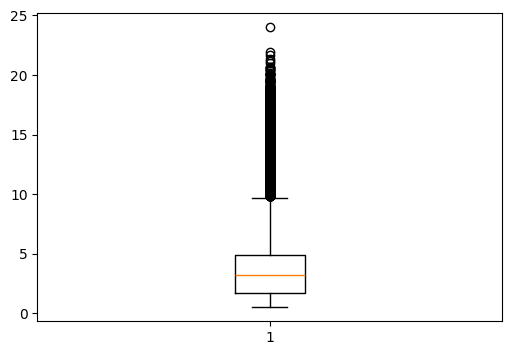

In [25]:
#Vamos fazer um boxplot da nossa variável e entender melhor como funciona esse diagrama.
#Estamos utilizando a biblioteca matplotlib, chamando a função figure para definir o tamanho
#do gráfico, da visualização. Primeiro, criamos o boxplot básico:


plt.figure(figsize=(6, 4))
plt.boxplot(tempo, vert=True)



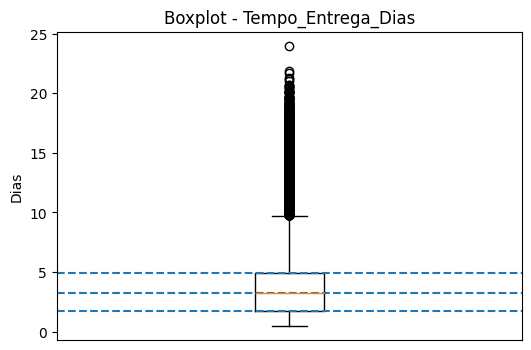

In [26]:
#Em seguida, adicionamos mais detalhes ao gráfico para torná-lo mais informativo:

plt.figure(figsize=(6, 4))
plt.boxplot(tempo, vert=True)

plt.axhline(q1, linestyle='--')
plt.axhline(q2, linestyle='--')
plt.axhline(q3, linestyle='--')

plt.title("Boxplot - Tempo_Entrega_Dias")
plt.ylabel("Dias")
plt.xticks([])
plt.show()


In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Estilo visual padrão dos gráficos
sns.set(style="whitegrid")

#Dataset sintético simples:
np.random.seed(42)

df = pd.DataFrame({
    "salario": np.concatenate([
        np.random.normal(3000, 500, 900),
        np.random.normal(12000, 2000, 100)
    ]),
    "idade": np.random.randint(18, 70, 1000),
    "canal": np.random.choice(["Online", "Loja Física", "App"], 1000, p=[0.5, 0.3, 0.2])
})

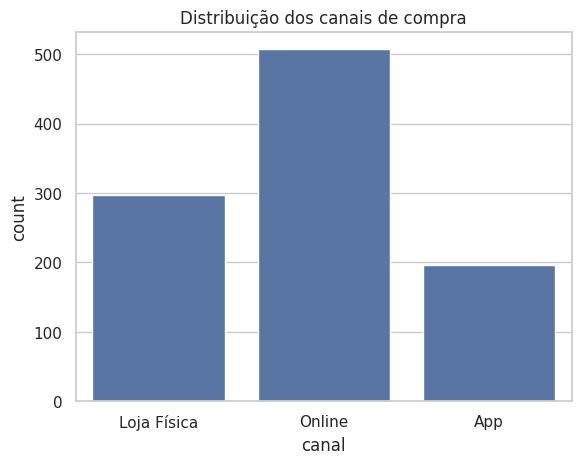

In [28]:
# Exemplo: Canal de compra
sns.countplot(data=df, x="canal")
plt.title("Distribuição dos canais de compra")
plt.show()

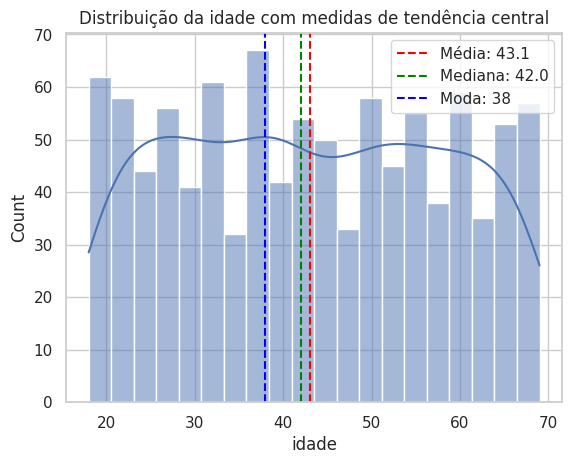

In [29]:
#Variáveis discretas (como idade, número de compras, número de acessos)
#permitem todas as medidas de tendência central.

#Exemplo: Idade
media = df["idade"].mean()
mediana = df["idade"].median()
moda = df["idade"].mode()[0]

sns.histplot(df["idade"], bins=20, kde=True)
plt.axvline(media, color="red", linestyle="--", label=f"Média: {media:.1f}")
plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana}")
plt.axvline(moda, color="blue", linestyle="--", label=f"Moda: {moda}")
plt.legend()
plt.title("Distribuição da idade com medidas de tendência central")
plt.show()

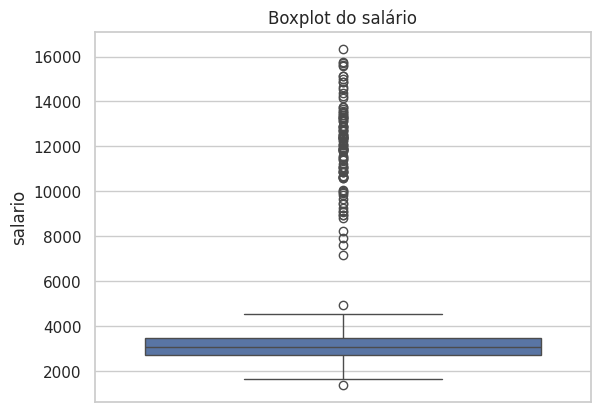

In [30]:
#O boxplot é o gráfico mais direto para visualizar mediana, quartis e valores extremos (outliers).

sns.boxplot(y=df["salario"])
plt.title("Boxplot do salário")
plt.show()

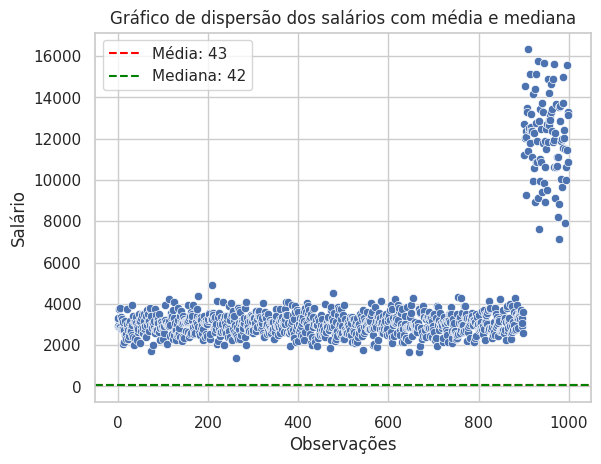

In [31]:
sns.scatterplot(
    x=df.index,
    y=df["salario"]
)

plt.axhline(media, color="red", linestyle="--", label=f"Média: {media:.0f}")
plt.axhline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana:.0f}")
plt.legend()
plt.title("Gráfico de dispersão dos salários com média e mediana")
plt.xlabel("Observações")
plt.ylabel("Salário")
plt.show()

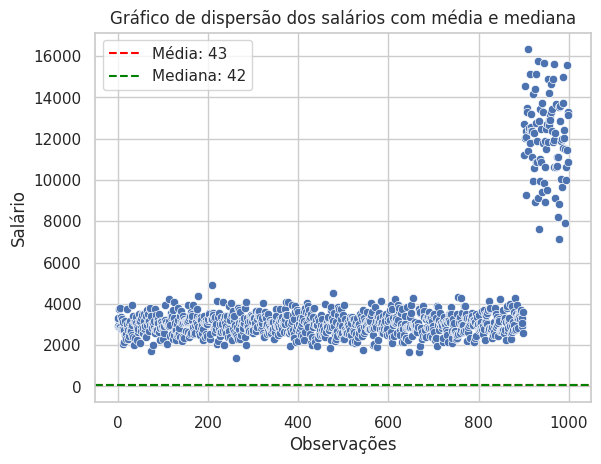

In [32]:
sns.scatterplot(
    x=df.index,
    y=df["salario"]
)

plt.axhline(media, color="red", linestyle="--", label=f"Média: {media:.0f}")
plt.axhline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana:.0f}")
plt.legend()
plt.title("Gráfico de dispersão dos salários com média e mediana")
plt.xlabel("Observações")
plt.ylabel("Salário")
plt.show()

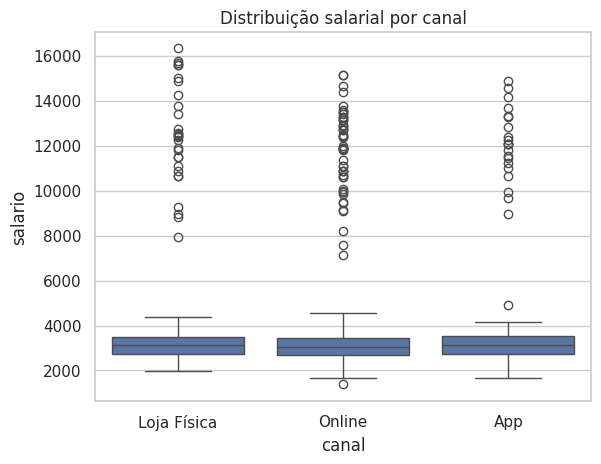

In [33]:
#Exemplo: Salário por canal de compra
sns.boxplot(data=df, x="canal", y="salario")
plt.title("Distribuição salarial por canal")
plt.show()